# Practice 1 – Data & Indicators

In [78]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267952,72.306521,70.568525,70.819223,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [80]:
#data = data[['Adj Close']].dropna()
data = data[['Close']].dropna()
data['returns'] = data['Close'].pct_change()
data.head()

Price,Close,returns
Ticker,AAPL,
Date,,
2020-01-02,72.400505,NaN
2020-01-03,71.696640,-0.009722
2020-01-06,72.267952,0.007968
2020-01-07,71.928070,-0.004703
2020-01-08,73.085106,0.016086


## Moving Averages

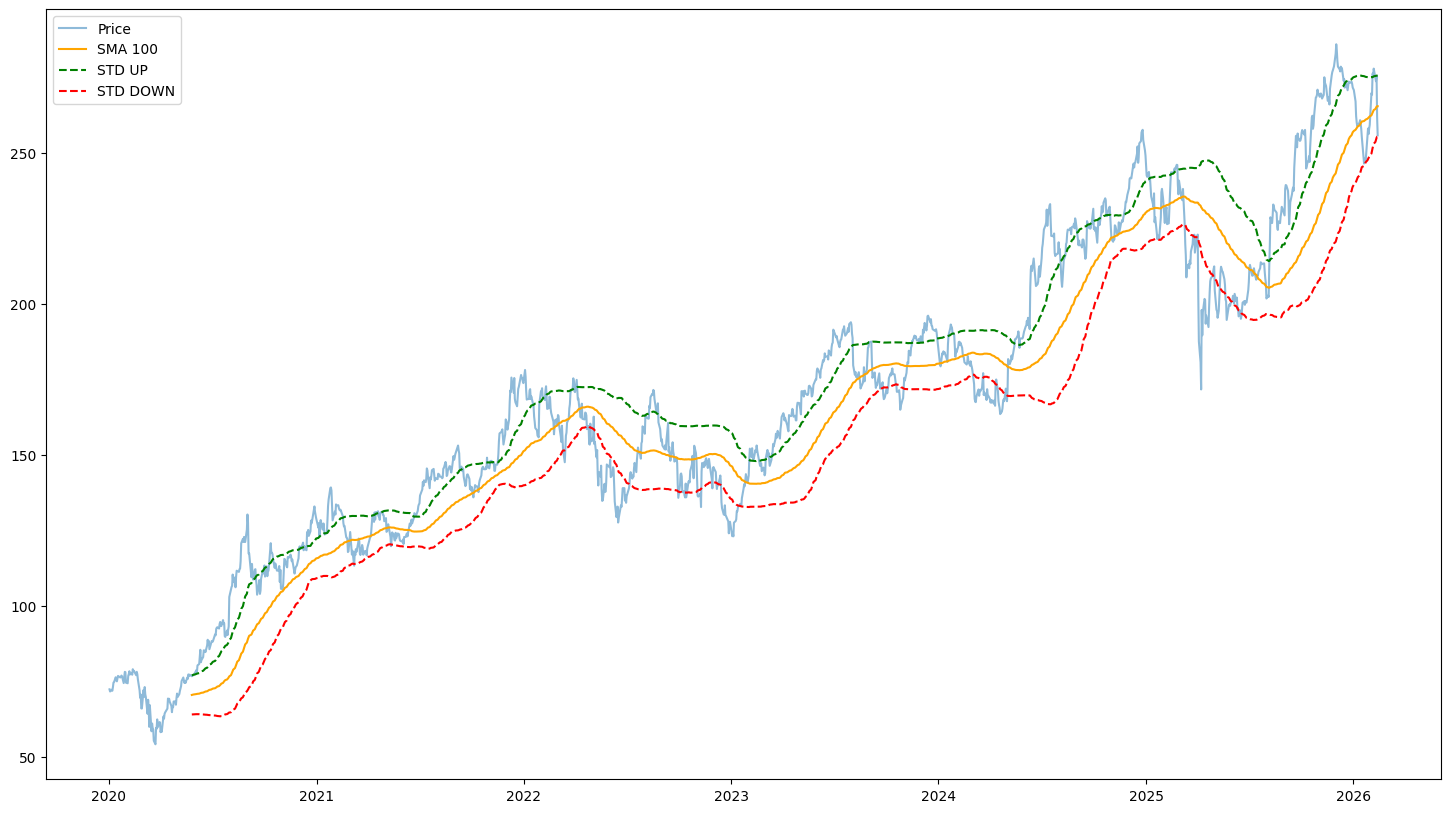

In [81]:
data_interval = 100

rolling_window = data['Close'].rolling(data_interval)

data['SMA'] = rolling_window.mean()
data['STD'] = rolling_window.std()

data['STD_UP'] = data['SMA'] + data['STD']
data['STD_DOWN'] = data['SMA'] - data['STD']

plt.figure(figsize=(18, 10))
plt.plot(data['Close'], label='Price', alpha=0.5)
plt.plot(data['SMA'], label=f'SMA {data_interval}', color='orange')

plt.plot(data['STD_UP'], label='STD UP', linestyle='--', color='green')
plt.plot(data['STD_DOWN'], label='STD DOWN', linestyle='--', color='red')

plt.legend()
plt.show()

## RSI

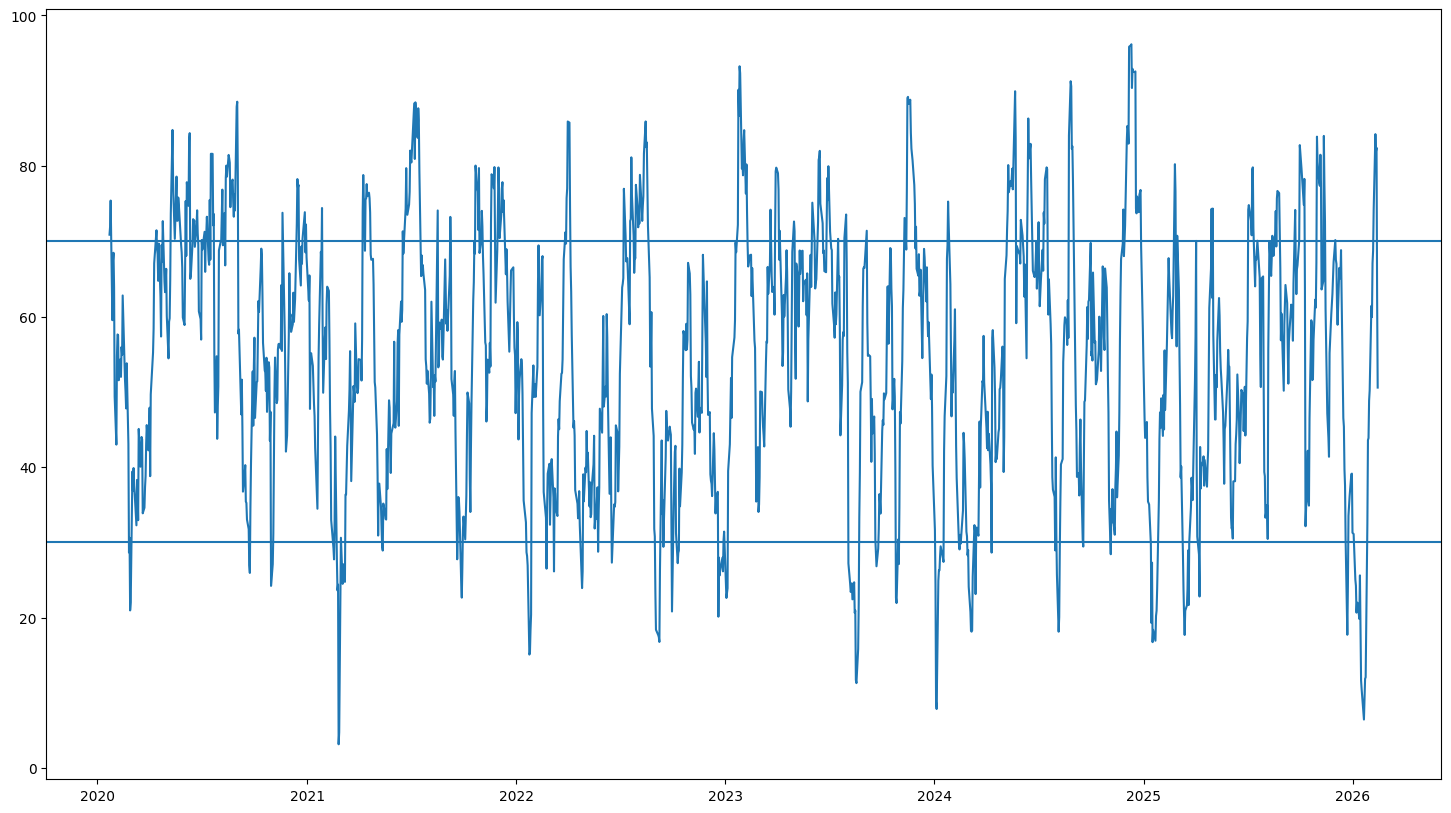

In [82]:
#RSI compares average gains and average losses over the last 14 days
#If recent gains are much larger than losses → market may be overbought
#If recent losses dominate → market may be oversold

delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

plt.figure(figsize=(18, 10))
plt.plot(data['RSI'])
plt.axhline(70)
plt.axhline(30)
plt.show()